# Descripcipción del proyecto

Film Junky Union, una nueva comunidad vanguardista para los aficionados de las películas clásicas, está desarrollando un sistema para filtrar y categorizar reseñas de películas. Tu objetivo es entrenar un modelo para detectar las críticas negativas de forma automática. Para lograrlo, utilizarás un conjunto de datos de reseñas de películas de IMDB con leyendas de polaridad para construir un modelo para clasificar las reseñas positivas y negativas. Este deberá alcanzar un valor F1 de al menos 0.85.

## Inicialización

In [1]:
# Importación de librerías

import math
import re
import spacy

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

import sklearn.metrics as metrics

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report
import nltk
from transformers import BertModel

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords
from lightgbm import LGBMClassifier
import joblib

import torch
import transformers
       

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

# la siguiente línea proporciona gráficos de mejor calidad en pantallas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# esto es para usar progress_apply, puedes leer más en https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Cargar datos

In [4]:
# Importación de datos
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
# Mostrar información del dataframe
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [6]:
# Verificar valores duplicados
df_reviews.duplicated().sum()

0

In [7]:
# Verificar valores nulos
df_reviews.isnull().sum()

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64

Debido a que el numero de valores nulos dentro de la basa de datos es baja, se puede eliminar los mismos sin generar errores mas adelante.

In [8]:
# Eliminar filas con valores nulos
df_reviews = df_reviews.dropna()

In [9]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 47329 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47329 non-null  object 
 1   title_type       47329 non-null  object 
 2   primary_title    47329 non-null  object 
 3   original_title   47329 non-null  object 
 4   start_year       47329 non-null  int64  
 5   end_year         47329 non-null  object 
 6   runtime_minutes  47329 non-null  object 
 7   is_adult         47329 non-null  int64  
 8   genres           47329 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47329 non-null  object 
 12  rating           47329 non-null  int64  
 13  sp               47329 non-null  object 
 14  pos              47329 non-null  int64  
 15  ds_part          47329 non-null  object 
 16  idx              47329 non-null  int64  
dtypes: Int64(1),

## EDA

Veamos el número de películas y reseñas a lo largo de los años.

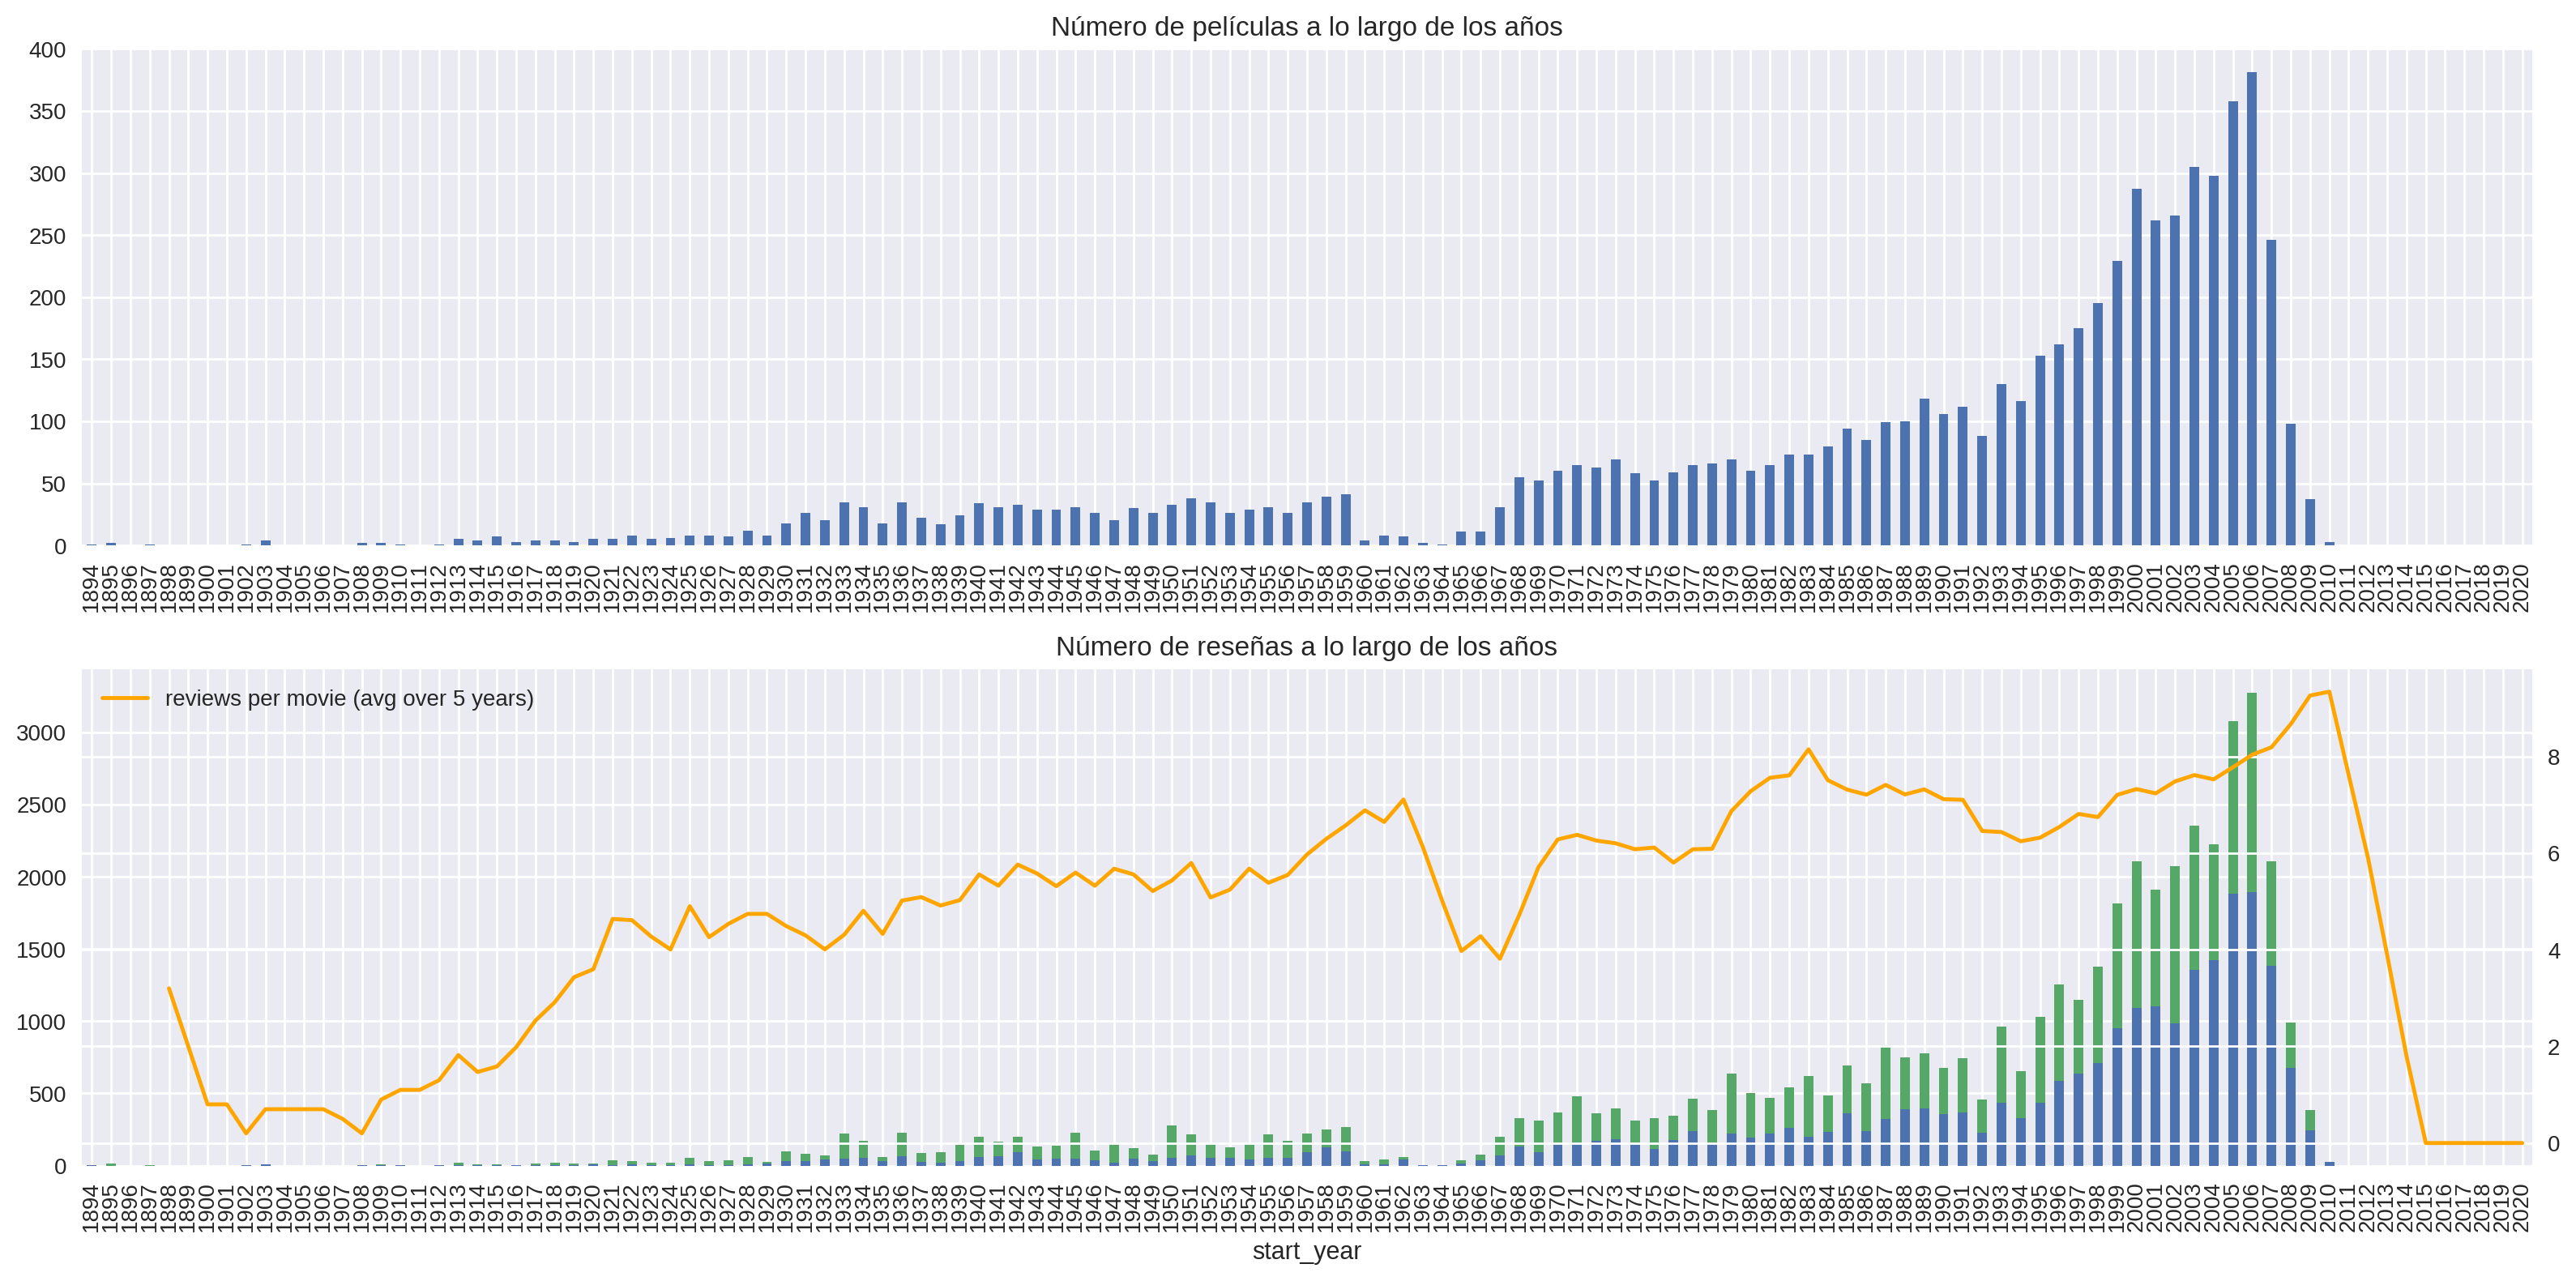

In [10]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de reseñas a lo largo de los años')

fig.tight_layout()

Veamos la distribución del número de reseñas por película con el conteo exacto y KDE (solo para saber cómo puede diferir del conteo exacto)

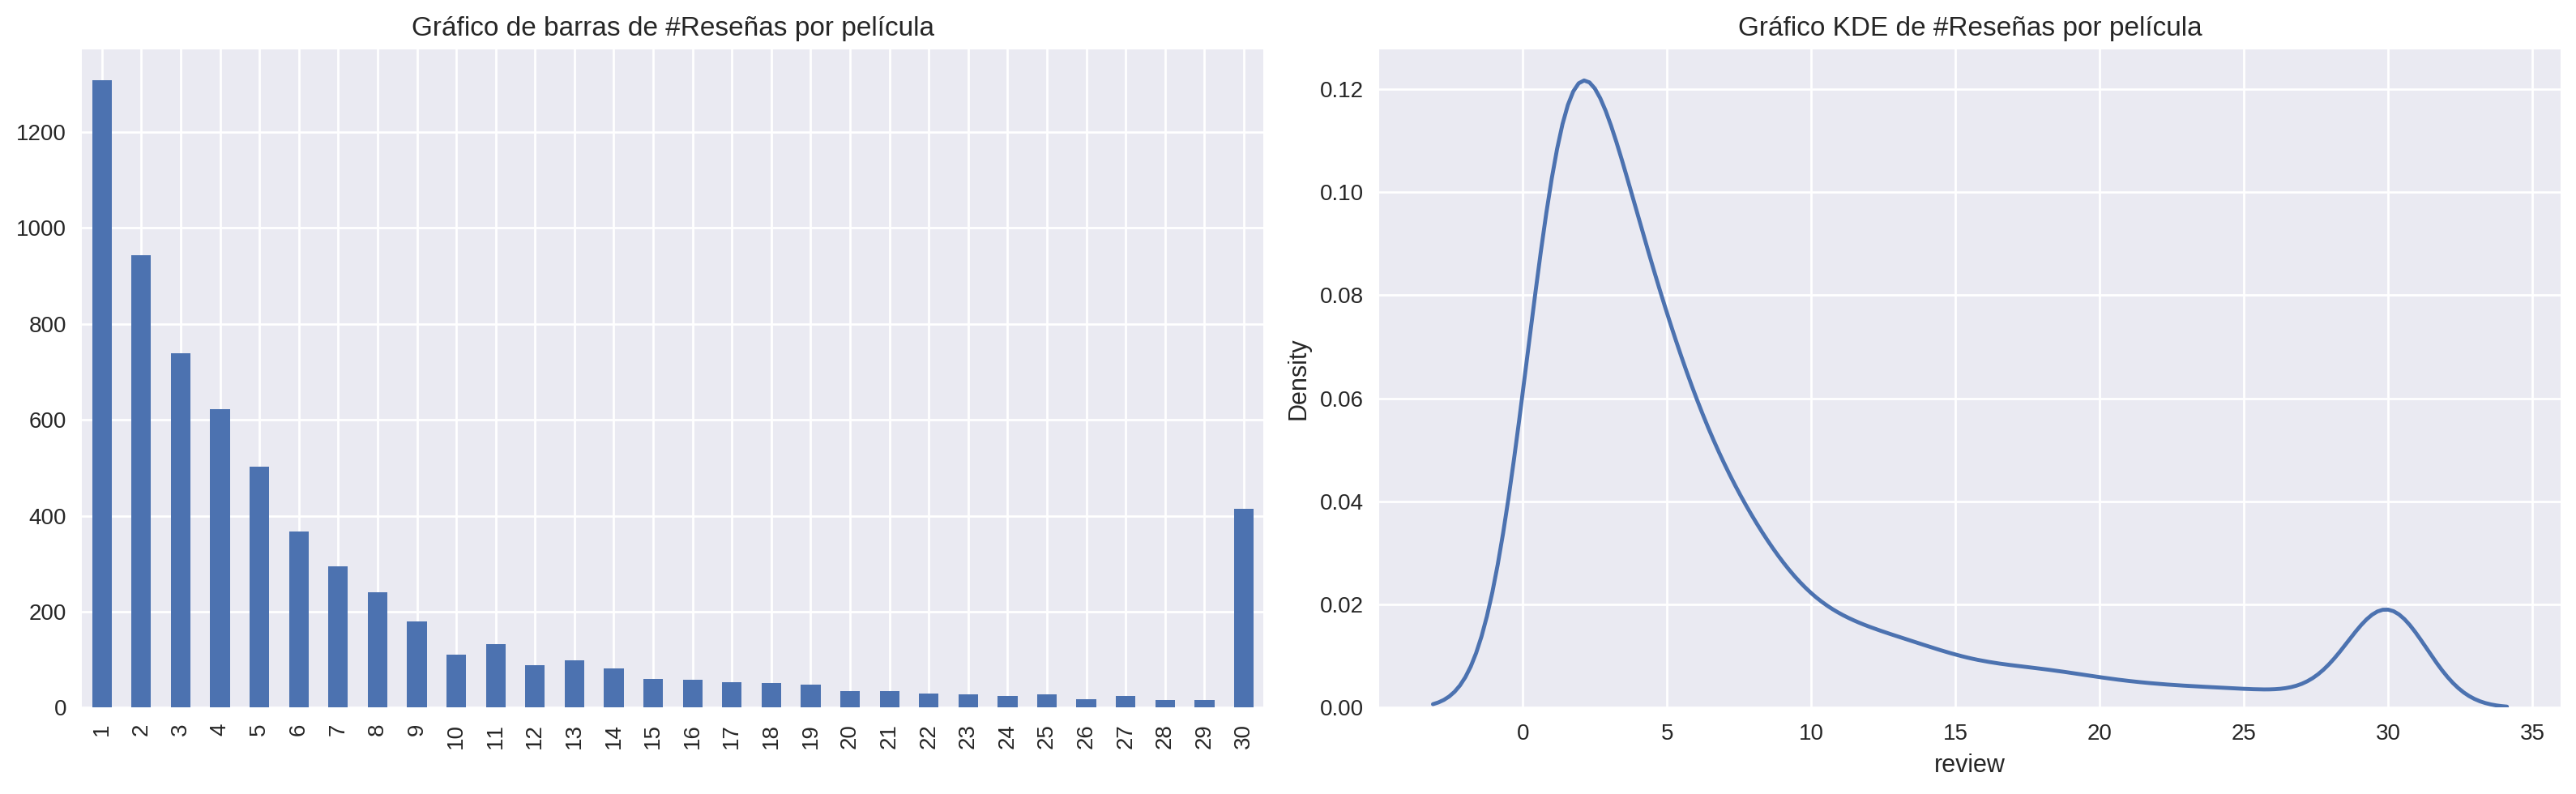

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de barras de #Reseñas por película')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico KDE de #Reseñas por película')

fig.tight_layout()

In [12]:
df_reviews['pos'].value_counts()

0    23715
1    23614
Name: pos, dtype: int64

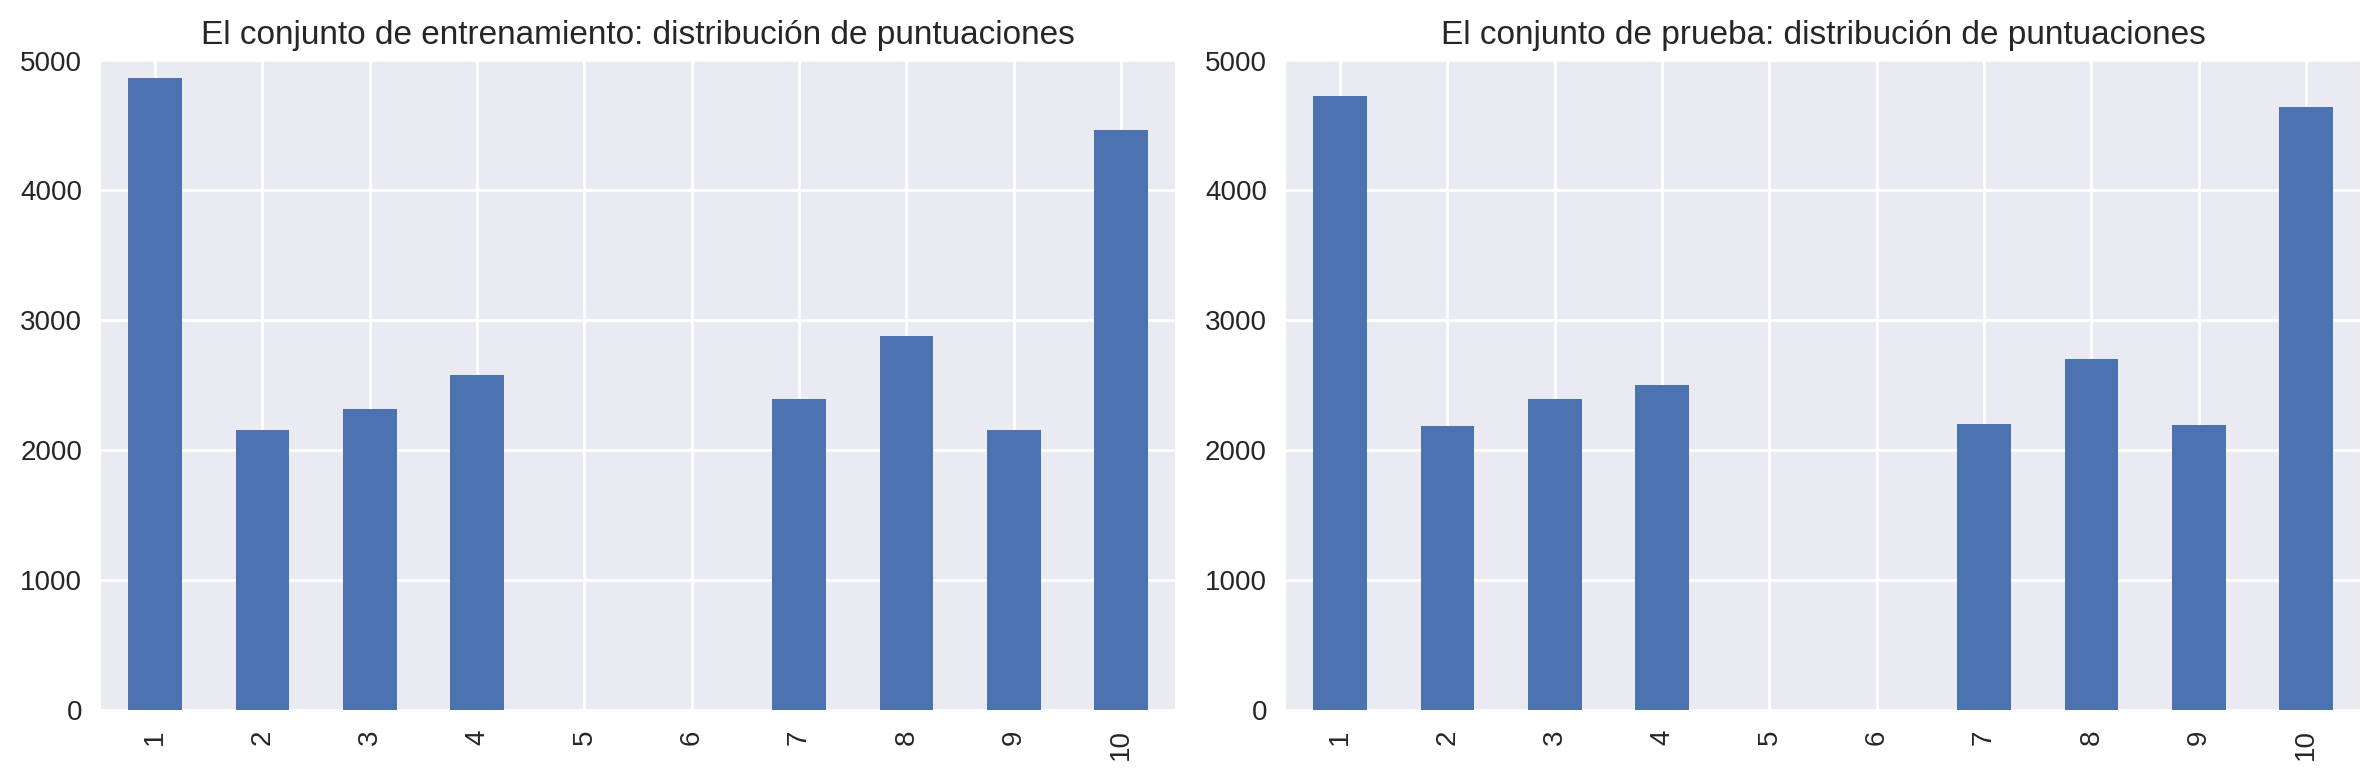

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de prueba: distribución de puntuaciones')

fig.tight_layout()

### Análisis del desequilibrio de clases

- **Aumento de reseñas por año:** Se puede observar un incremento significativo en el numero de reseñas hasta alcanzar un máximo en 2007. Esto puede deberse a una mayor popularidad del producto o mejores campañas de marketing que incentivaron a los usuarios a dejar sus opiniones. Sin embargo, después del 2007, se originó una caida drástica en el número de reseñas hasta desaparecer completamente en 2011, lo que pudo haber indicado un cambio drástico en la dinámica del mercado como la entrada de competidores o la disminución de la relevancia del producto.


- **Comparación entre conjuntos Entrenamiento - Prueba:** Se observa que ambos conjuntos de datos muestran una distribución temporal similar, lo cual es positivo ya que indica que la división de los datos preservó esta distribución. Sin embargo, se identifica una caída abrupta en el número de reseñas después de 2007 en ambos conjuntos, lo que podría limitar la capacidad del modelo para generalizar sobre reseñas más recientes.


- **Distribución de puntuciones Positivas - Negativas:** La distribución balanceada entre reseñas positivas y negativas es importante porque previene el desequilibrio de clases. Un desequilibrio de clases podría sesgar el modelo hacia la clase mayoritaria y afectar negativamente la precisión de las predicciones.

Distribución de reseñas negativas y positivas a lo largo de los años para dos partes del conjunto de datos

/opt/conda/envs/python3/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/opt/conda/envs/python3/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/opt/conda/envs/python3/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/opt/conda/envs/python3/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


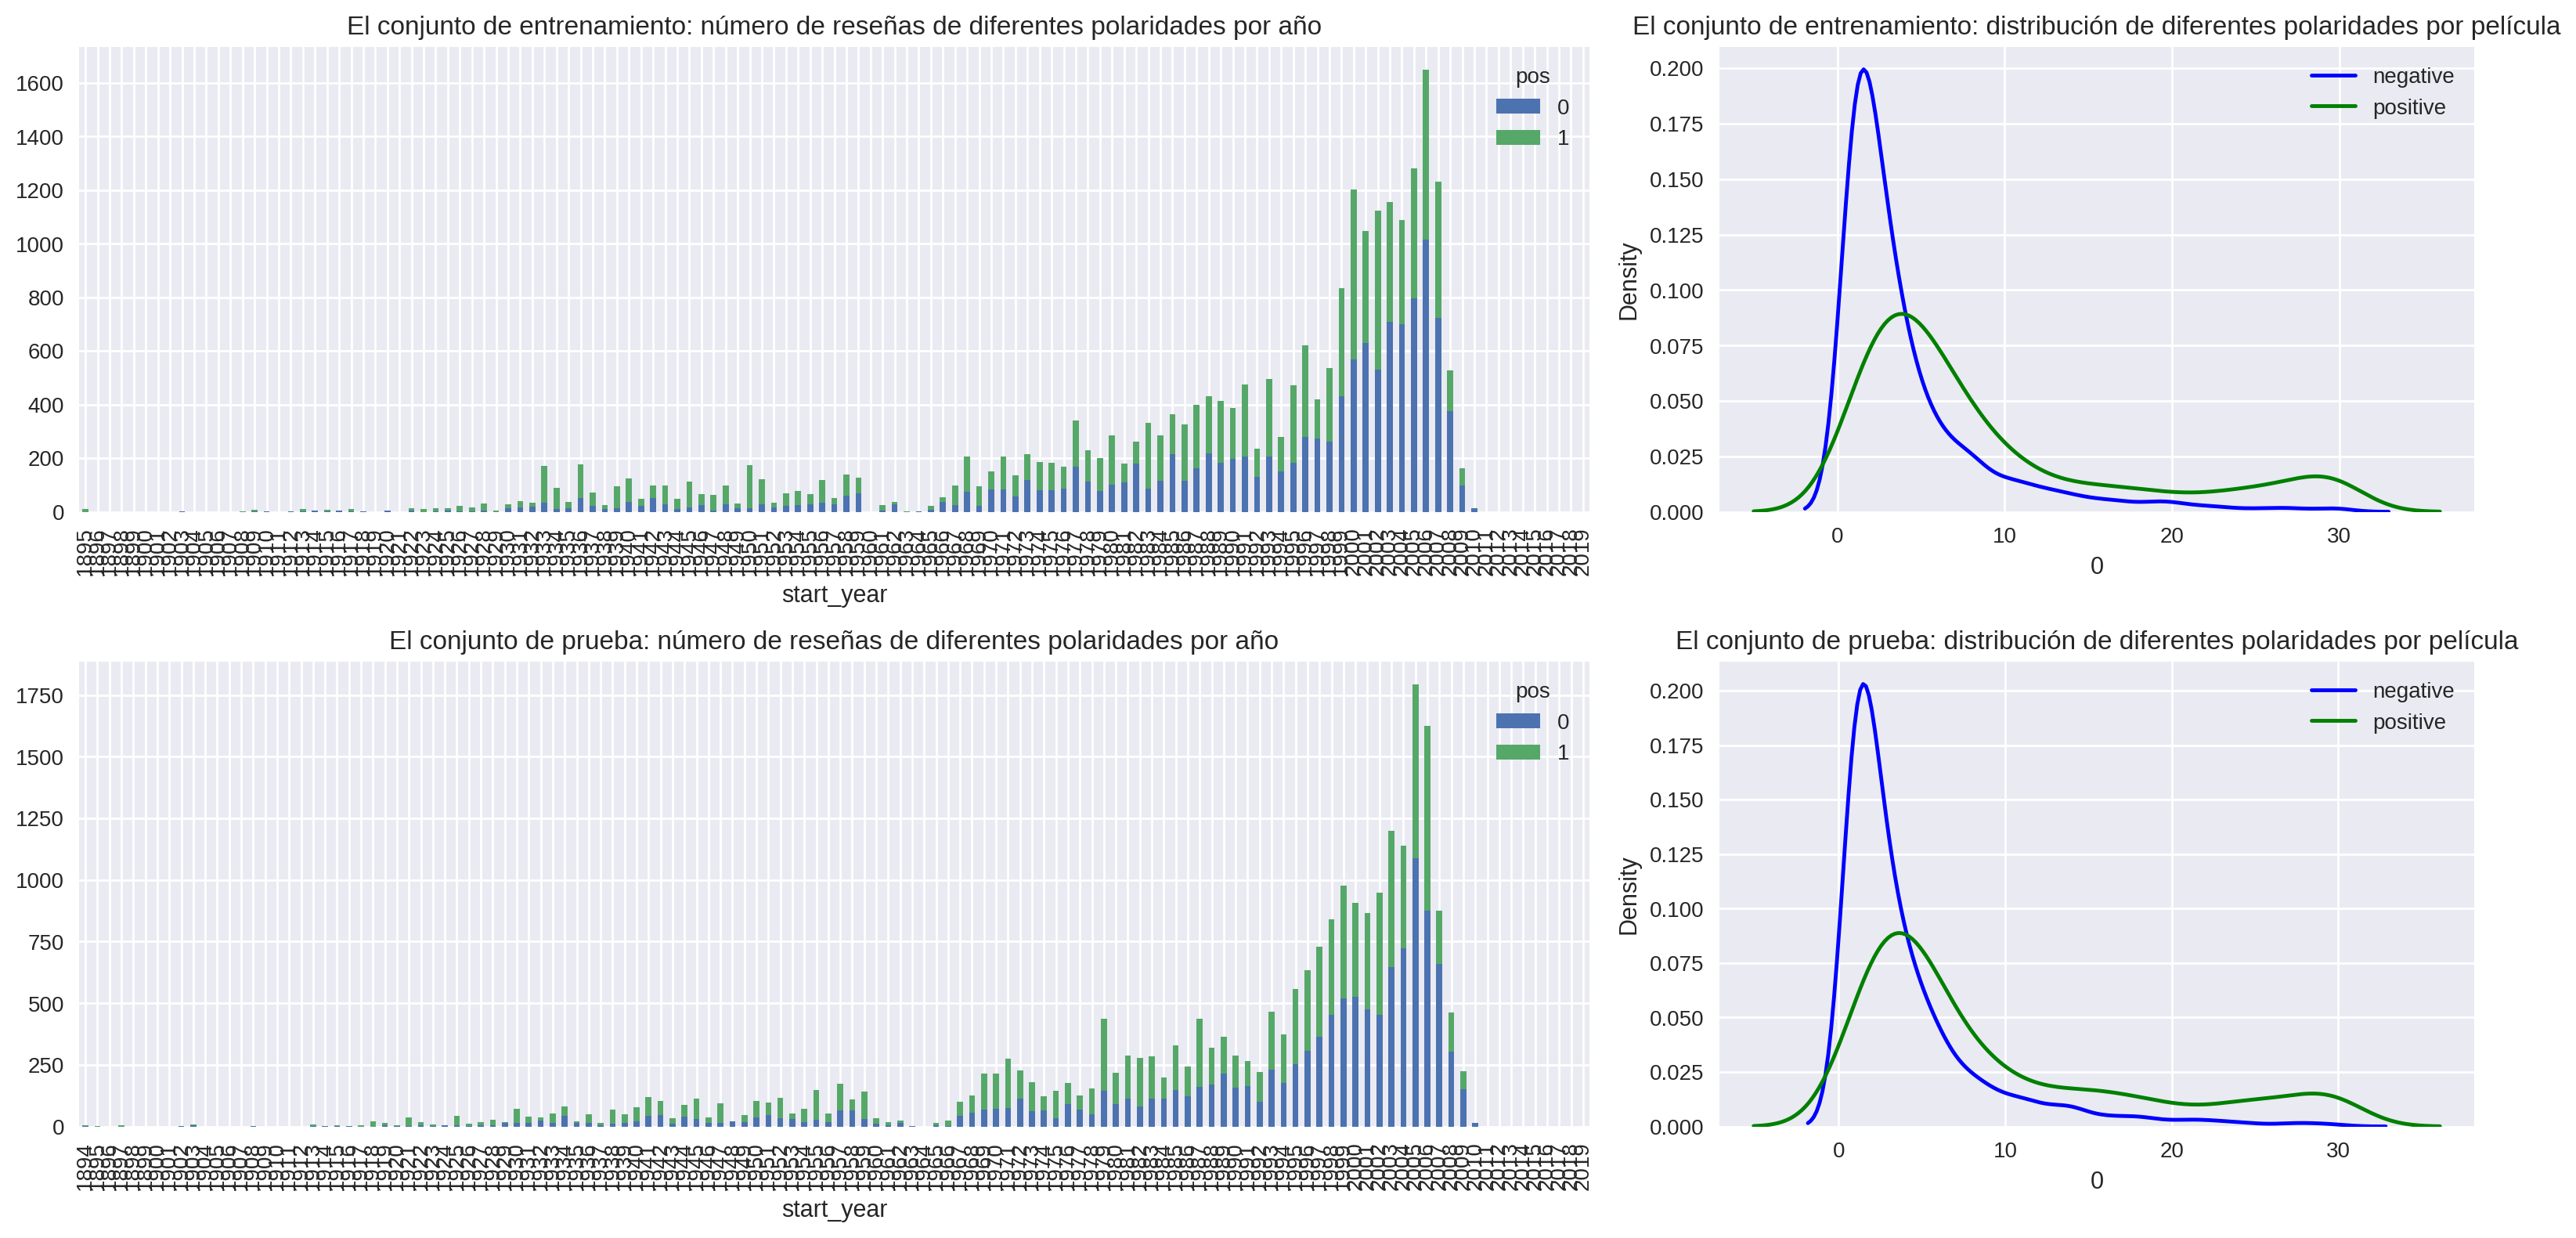

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de entrenamiento: número de reseñas de diferentes polaridades por año')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de entrenamiento: distribución de diferentes polaridades por película')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de prueba: número de reseñas de diferentes polaridades por año')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de prueba: distribución de diferentes polaridades por película')

fig.tight_layout()

## Procedimiento de evaluación

Composición de una rutina de evaluación que se pueda usar para todos los modelos en este proyecto

In [15]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
#     df_eval_stats = df_eval_stats.reindex(index=('Exactitud', 'F1', 'APS', 'ROC AUC'))
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalización

Suponemos que todos los modelos a continuación aceptan textos en minúsculas y sin dígitos, signos de puntuación, etc.

In [16]:
# Convertir a numpy arrays antes de llamar a evaluate_model
def convert_to_numpy(*args):
    return [arg.to_numpy() if isinstance(arg, pd.Series) else np.array(arg) for arg in args]

In [17]:
# Función para normalizar el texto
def normalize_text(text):
    
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar dígitos
    text = re.sub(r'\d+', '', text)
    # Eliminar signos de puntuación
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

In [18]:
# Aplicar la función de normalización a la columna 'review'
df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)

In [19]:
# Verificar la columna 'review_norm'
df_reviews['review_norm']

0        the pakage implies that warren beatty and gold...
1        how the hell did they get this made presenting...
2        there is no real story the film seems more lik...
3        um  a serious film about troubled teens in sin...
4        im totally agree with garryjohal from singapor...
                               ...                        
47326    this is another of my favorite columbos it spo...
47327    talk about being boring i got this expecting a...
47328    i never thought id say this about a biopic but...
47329    spirit and chaos is an artistic biopic of miya...
47330    ill make this brief this was a joy to watch it...
Name: review_norm, Length: 47329, dtype: object

## División entrenamiento / prueba

Por fortuna, todo el conjunto de datos ya está dividido en partes de entrenamiento/prueba; 'ds_part' es el indicador correspondiente.

In [20]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23533, 18)


## Trabajar con modelos

### Modelo 0 - Constante

El modelo constante es un modelo básico que sirve como punto de referencia. Utilizamos DummyClassifier para hacer predicciones que no dependen de los datos de entrada, sino que simplemente predicen una constante.

No handles with labels found to put in legend.


               Exactitud   F1  APS  ROC AUC
Entrenamiento        0.5  0.0    0        0
Prueba               0.5  0.0    0        0


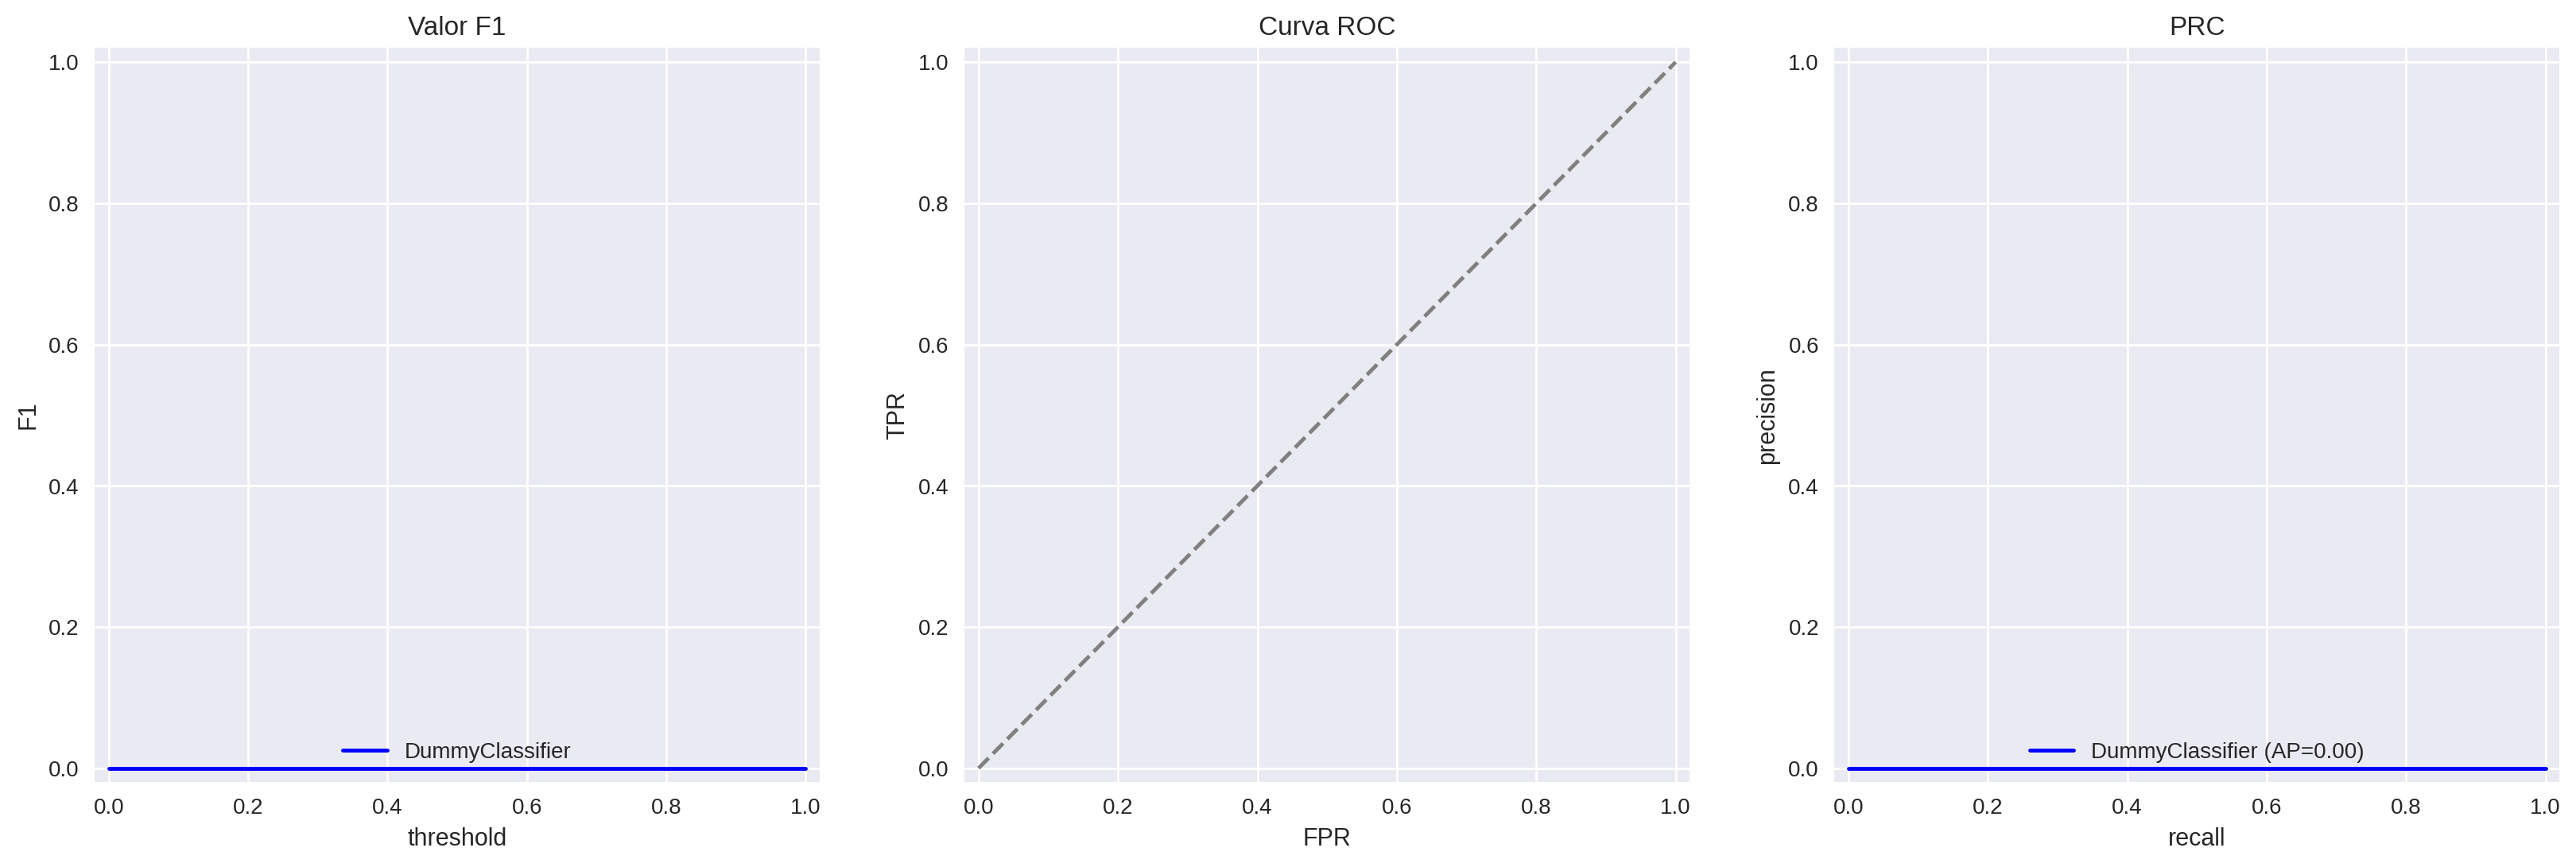

No handles with labels found to put in legend.


               Exactitud   F1  APS  ROC AUC
Entrenamiento        0.5  0.0    0        0
Prueba               0.5  0.0    0        0


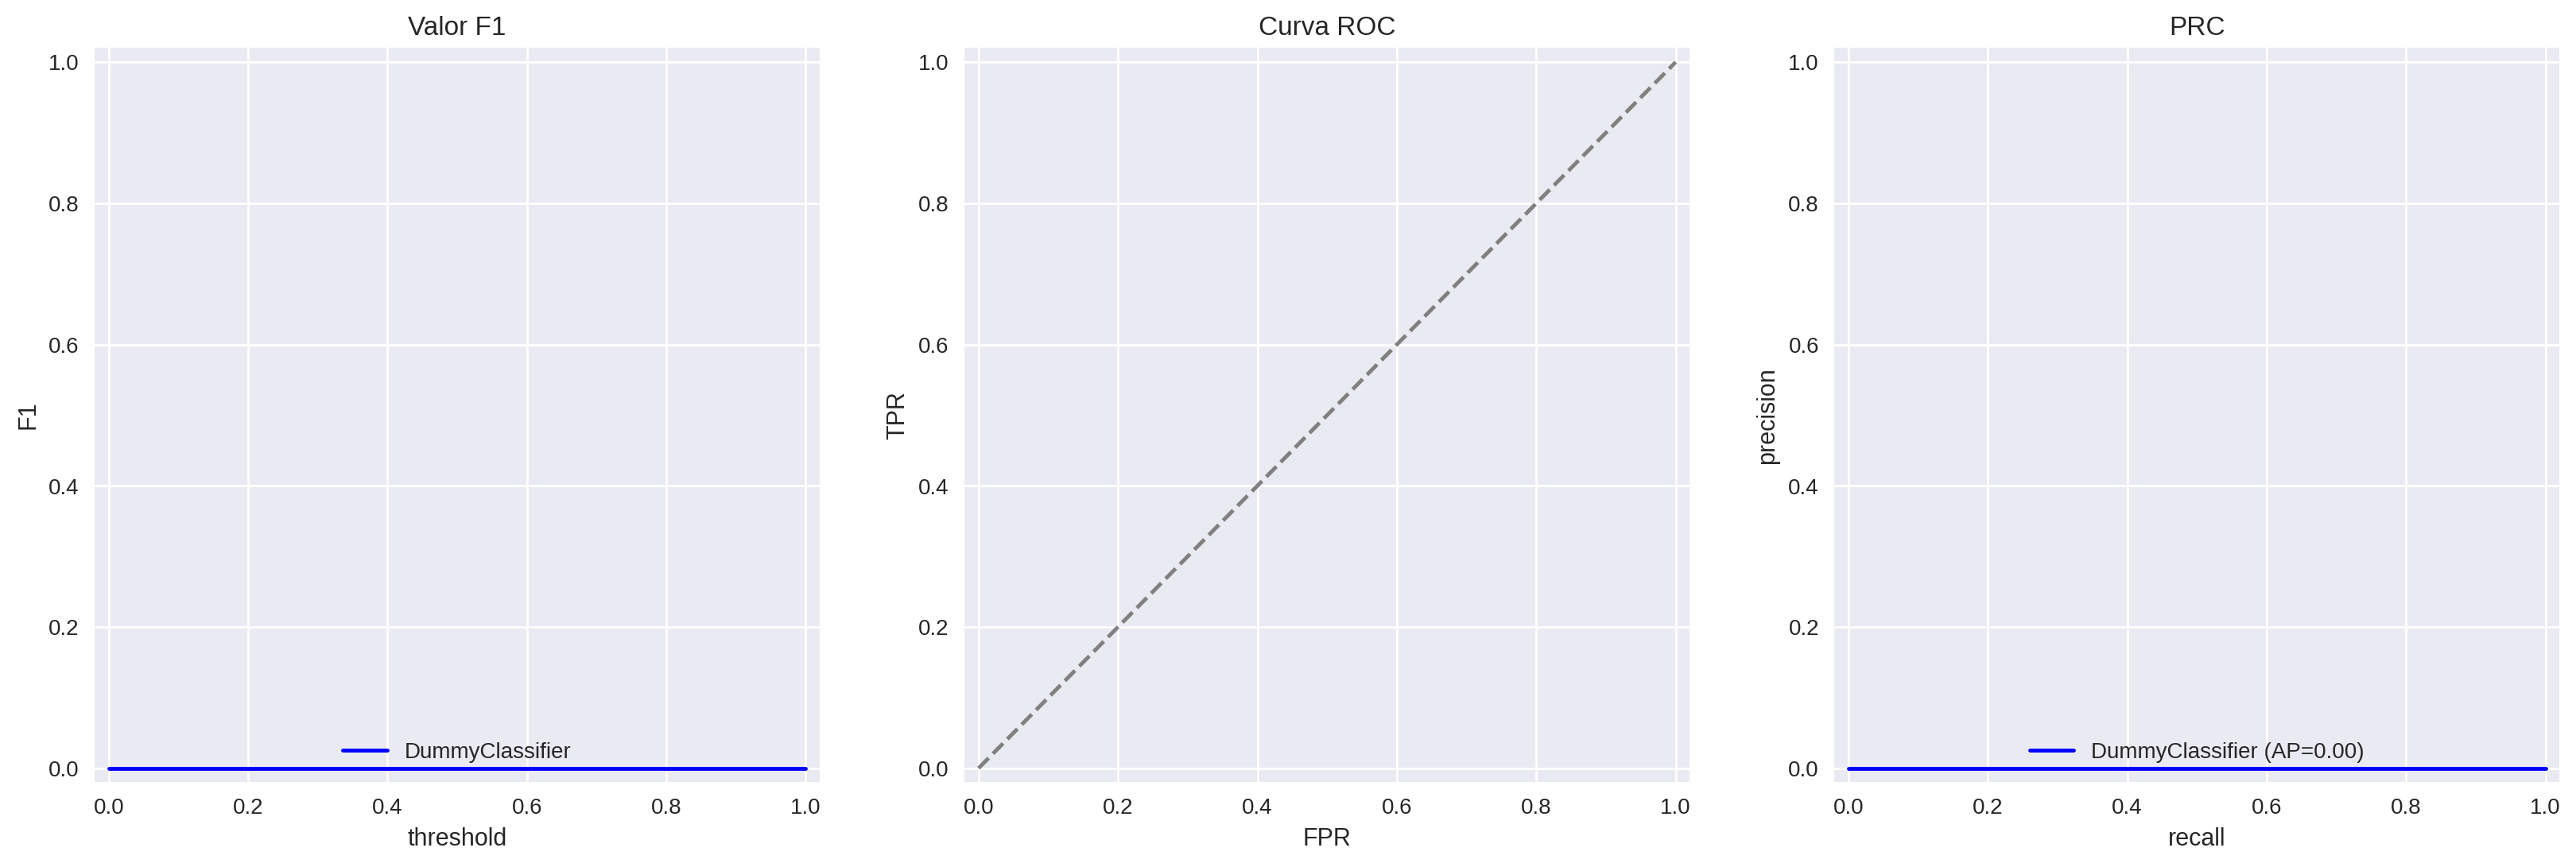

In [21]:
# Función para entrenar el DummyClassifier
def train_dummy_classifier(train_features, train_target):
    """Entrena un DummyClassifier y devuelve el modelo entrenado."""
    model = DummyClassifier(strategy='most_frequent')
    model.fit(train_features, train_target)
    return model

# Función para evaluar el DummyClassifier
def evaluate_dummy_classifier(model, train_features, train_target, test_features, test_target):
    """Evalúa el DummyClassifier y devuelve las métricas de rendimiento."""
    # Predicciones
    train_pred_target = model.predict(train_features)
    test_pred_target = model.predict(test_features)

    # Calcular métricas
    train_accuracy = metrics.accuracy_score(train_target, train_pred_target)
    test_accuracy = metrics.accuracy_score(test_target, test_pred_target)
    train_f1 = metrics.f1_score(train_target, train_pred_target, average='binary')
    test_f1 = metrics.f1_score(test_target, test_pred_target, average='binary')

    # Crear un DataFrame para mostrar las métricas
    df_eval_stats = pd.DataFrame({
        'Exactitud': [train_accuracy, test_accuracy],
        'F1': [train_f1, test_f1],
        'APS': [0, 0],  # DummyClassifier no tiene APS
        'ROC AUC': [0, 0]  # DummyClassifier no tiene ROC AUC
    }, index=['Entrenamiento', 'Prueba']).round(2)

    return df_eval_stats, train_pred_target, test_pred_target

def plot_metrics(train_pred_target, test_pred_target):
    """Genera gráficos de métricas para el DummyClassifier."""
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    # F1 Score
    f1_thresholds = np.arange(0, 1.01, 0.05)
    axs[0].plot(f1_thresholds, np.zeros_like(f1_thresholds), color='blue', label='DummyClassifier')
    axs[0].set_xlim([-0.02, 1.02])
    axs[0].set_ylim([-0.02, 1.02])
    axs[0].set_xlabel('threshold')
    axs[0].set_ylabel('F1')
    axs[0].legend(loc='lower center')
    axs[0].set_title('Valor F1')

    # ROC Curve
    axs[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
    axs[1].set_xlim([-0.02, 1.02])
    axs[1].set_ylim([-0.02, 1.02])
    axs[1].set_xlabel('FPR')
    axs[1].set_ylabel('TPR')
    axs[1].legend(loc='lower center')
    axs[1].set_title('Curva ROC')

    # PRC Curve
    axs[2].plot([0, 1], [0, 0], color='blue', label='DummyClassifier (AP=0.00)')
    axs[2].set_xlim([-0.02, 1.02])
    axs[2].set_ylim([-0.02, 1.02])
    axs[2].set_xlabel('recall')
    axs[2].set_ylabel('precision')
    axs[2].legend(loc='lower center')
    axs[2].set_title('PRC')

    plt.show()

# Entrenamiento y evaluación del DummyClassifier
dummy_model = train_dummy_classifier(df_reviews_train[['review_norm']], train_target)
df_eval_stats, train_pred_target, test_pred_target = evaluate_dummy_classifier(dummy_model, 
                                                                           df_reviews_train[['review_norm']], 
                                                                           train_target, 
                                                                           df_reviews_test[['review_norm']], 
                                                                           test_target)

print(df_eval_stats)
plot_metrics(train_pred_target, test_pred_target)

print(df_eval_stats)
plot_metrics(train_pred_target, test_pred_target)

La función evaluate_model evalúa modelos de clasificación que dan probabilidades y permiten ajustar el umbral de decisión.  DummyClassifier de sklearn no encaja bien con esto, pero sus métricas se usan de todas maneras.

Los gráficos de ROC y PRC salen vacíos porque DummyClassifier con la estrategia "most_frequent" siempre predice la clase más común, sin usar ninguna información.  Esto significa que no hay variación en las predicciones.

- **Curva ROC y ROC AUC:**  No hay curva ROC útil porque no hay verdaderos positivos ni falsos positivos variables.  El ROC AUC es 0.0.

- **Curva PRC:** No se puede calcular una curva PRC útil porque la precisión y el recall son constantes.

Se usan ceros como valores por defecto para estas métricas porque reflejan que el modelo no tiene capacidad predictiva real; solo adivina la clase más frecuente.

### Modelo 1 - NLTK, TF-IDF y LR

TF-IDF

In [22]:
# Descargar stopwords de NLTK
# nltk.download('stopwords')

stop_words = stopwords.words('english')

In [23]:
# Función para entrenar la regresión logística
def train_logistic_regression(train_features, train_target):
    model = LogisticRegression(max_iter=1000)
    model.fit(train_features, train_target)
    return model

In [24]:
# Configurar el TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords.words('english'), lowercase=True)

# Transformar las características textuales 
train_features_1 = tfidf_vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer.transform(df_reviews_test['review_norm'])

# Entrenamiento del modelo
model_1 = train_logistic_regression(train_features_1, train_target)

In [25]:
# Guardar el modelo entrenado
joblib.dump(model_1, 'model_1.pkl')

# Guardar el vectorizador TF-IDF
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')


# Realizar predicciones
train_predictions_1 = model_1.predict(train_features_1)
test_predictions_1 = model_1.predict(test_features_1)
train_predictions_proba_1 = model_1.predict_proba(train_features_1)[:, 1]
test_predictions_proba_1 = model_1.predict_proba(test_features_1)[:, 1]

In [26]:
# Convertir los datos
train_target_array, test_target_array, train_predictions_array, test_predictions_array = convert_to_numpy(
    train_target, test_target, train_predictions_1, test_predictions_1)

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


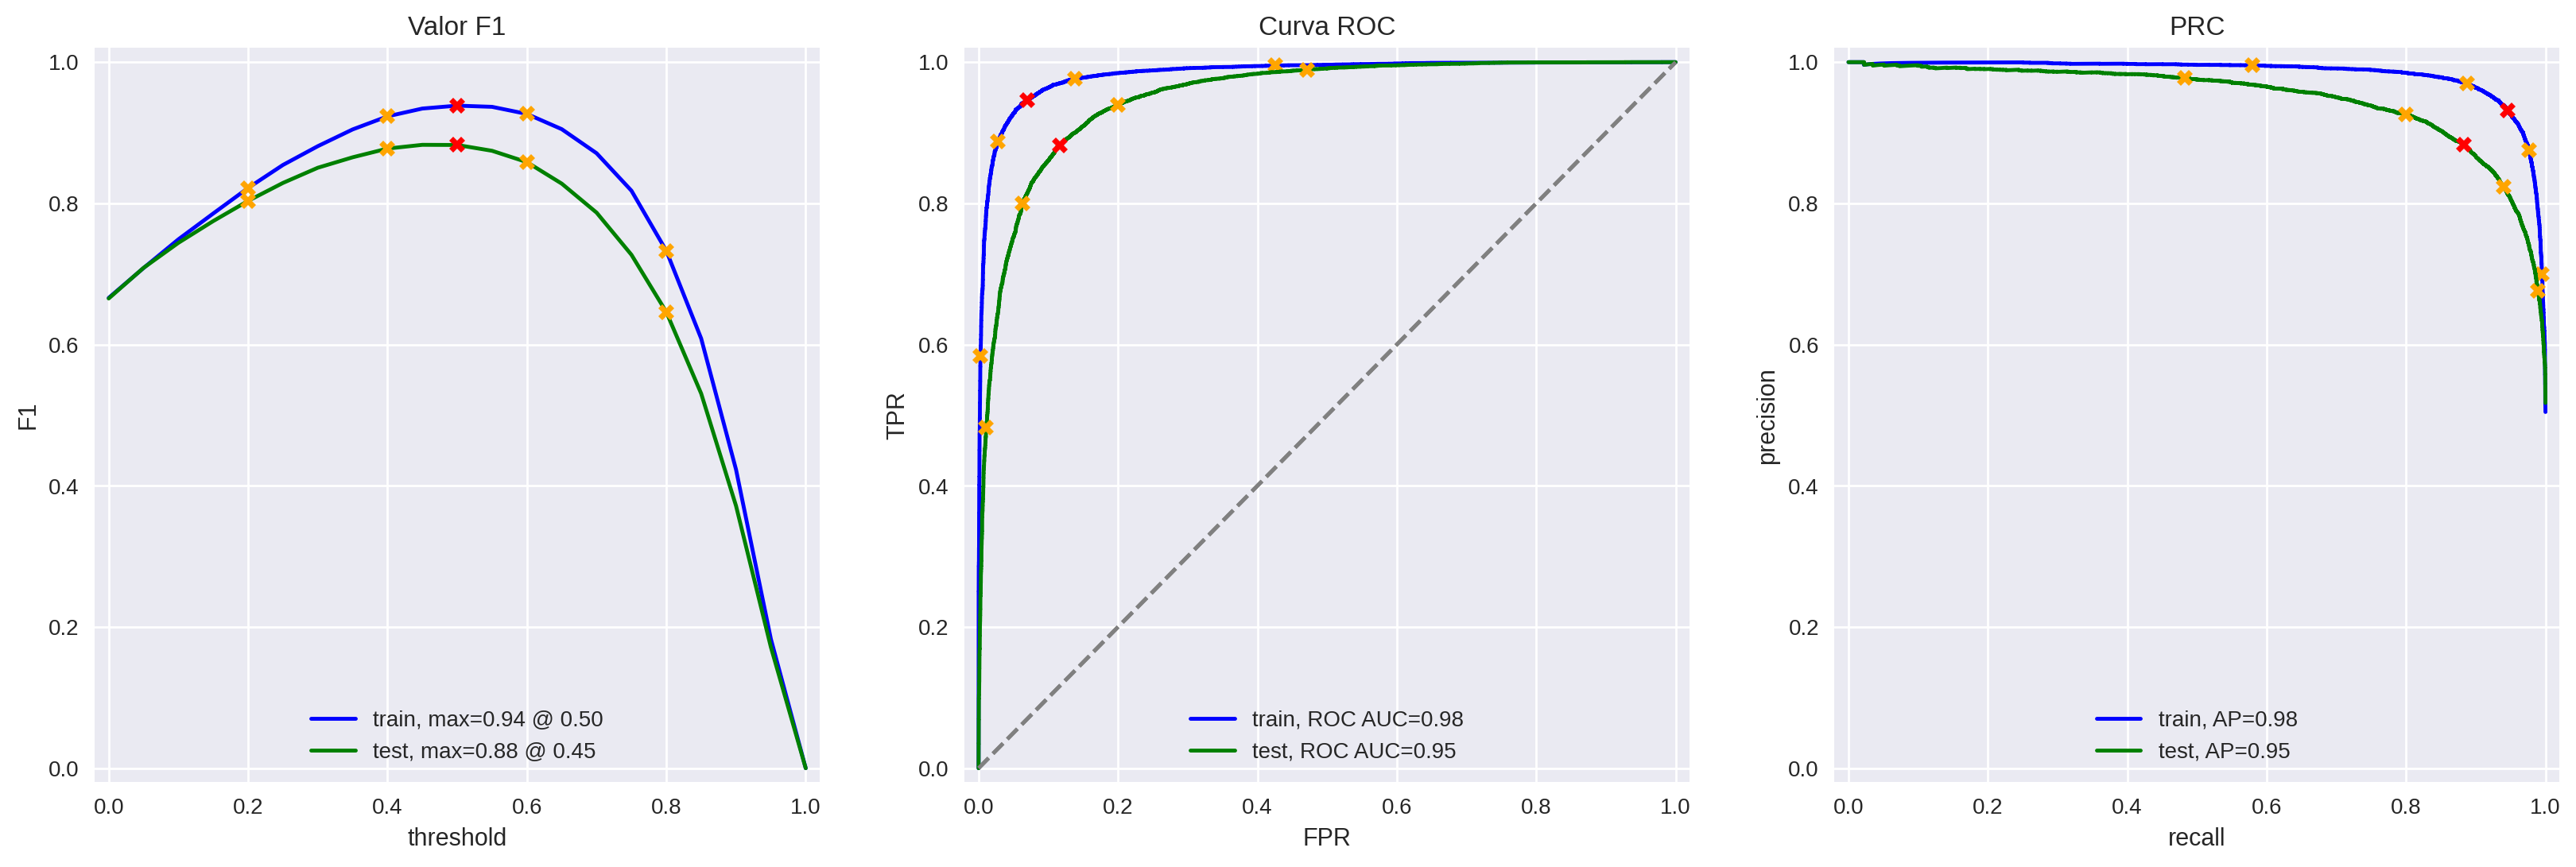

In [27]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Modelo 3 - spaCy, TF-IDF y LR

In [28]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [29]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [30]:
# Aplicar el preprocesamiento
df_reviews_train['processed_review'] = df_reviews_train['review_norm'].apply(text_preprocessing_3)
df_reviews_test['processed_review'] = df_reviews_test['review_norm'].apply(text_preprocessing_3)

In [31]:
# Configurar el TF-IDF Vectorizer
tfidf_vectorizer_3 = TfidfVectorizer()

In [32]:
# Transformar las características textuales
train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['processed_review'])
test_features_3 = tfidf_vectorizer_3.transform(df_reviews_test['processed_review'])

In [33]:
# Inicializar y entrenar el modelo de regresión logística
model_3 = LogisticRegression(max_iter=1000)
model_3.fit(train_features_3, train_target)

# Realizar predicciones
train_predictions_3 = model_3.predict(train_features_3)
test_predictions_3 = model_3.predict(test_features_3)
train_predictions_proba_3 = model_3.predict_proba(train_features_3)[:, 1]
test_predictions_proba_3 = model_3.predict_proba(test_features_3)[:, 1]


# Guardar el modelo
joblib.dump(model_3, 'model_3.pkl')

# Guardar el vectorizador TF-IDF
joblib.dump(tfidf_vectorizer_3, 'tfidf_vectorizer_3.pkl')

['tfidf_vectorizer_3.pkl']

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


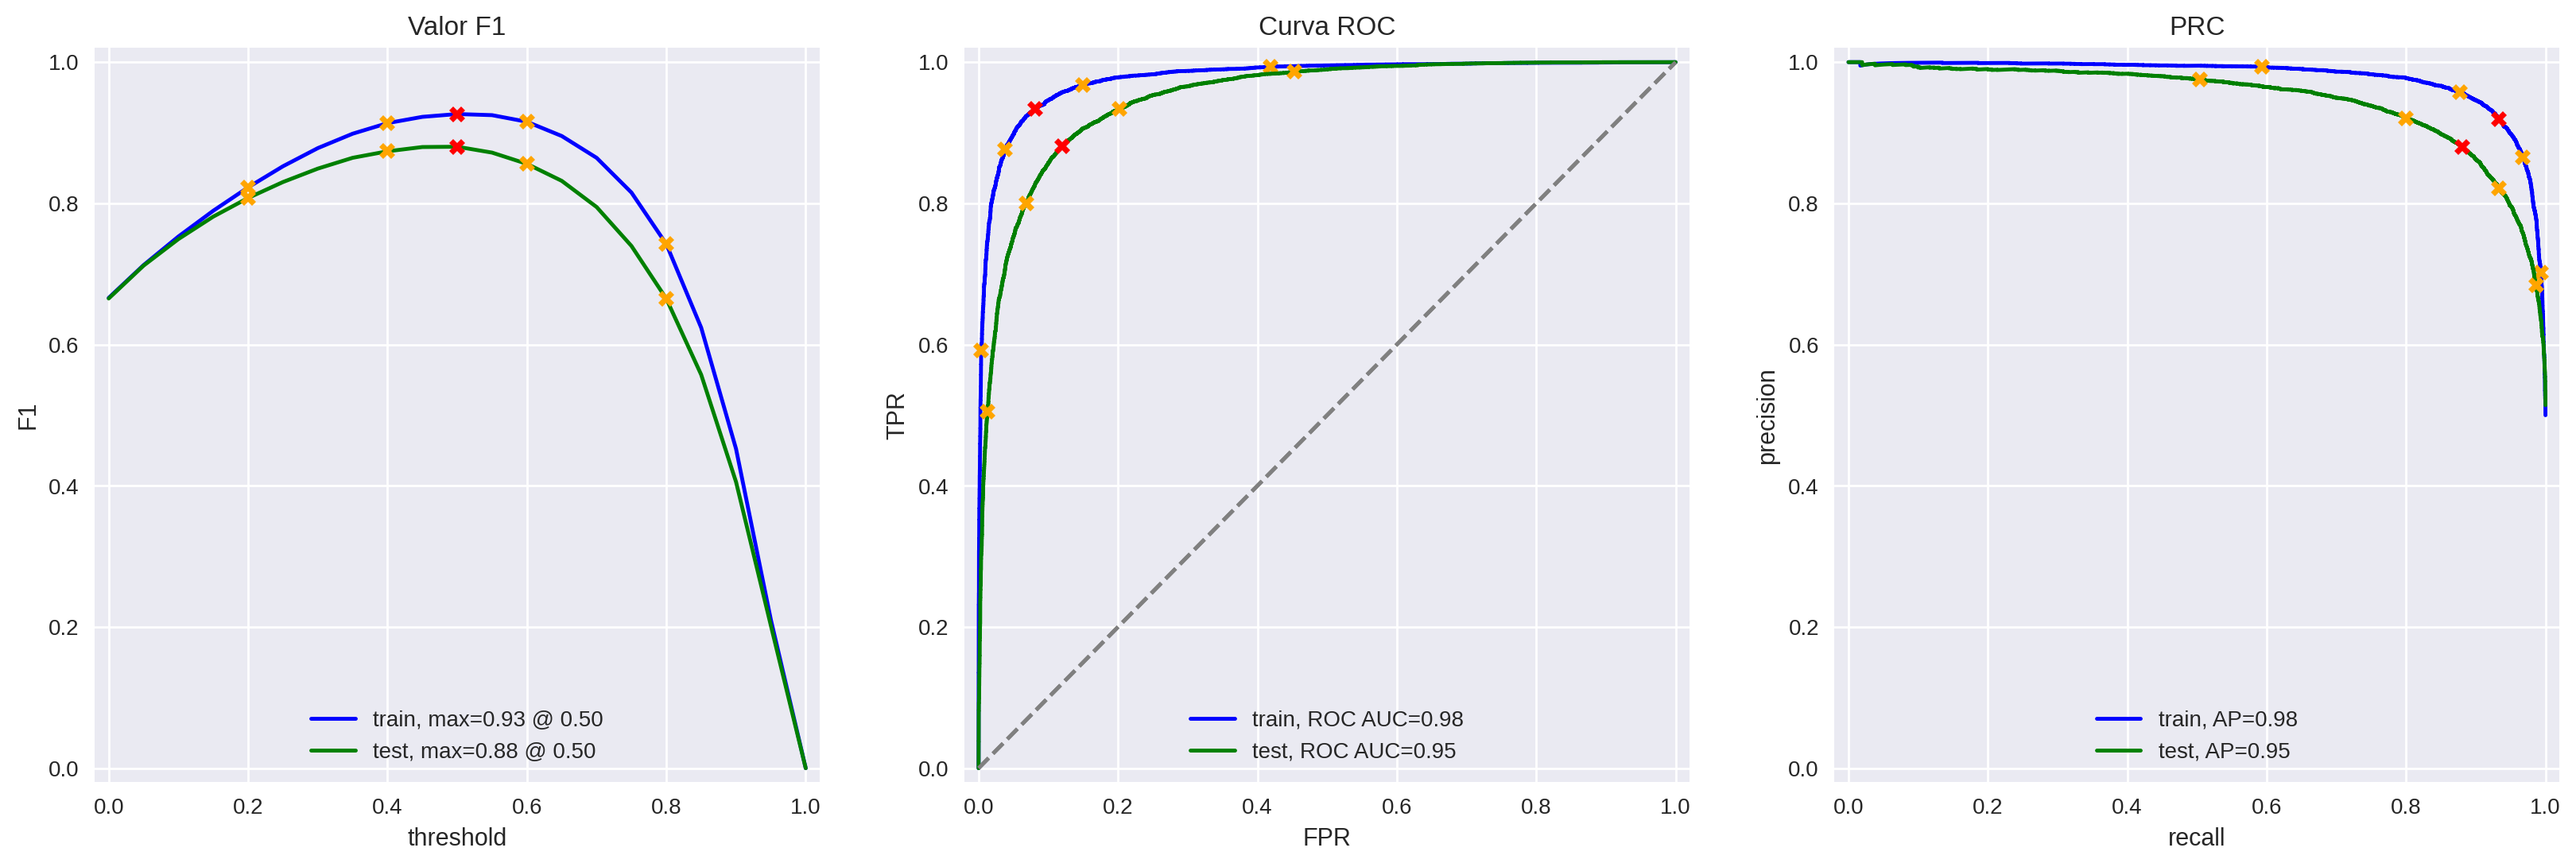

In [34]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

### Modelo 4 - spaCy, TF-IDF y LGBMClassifier

In [35]:
#  Función de Preprocesamiento para el Modelo 4

def text_preprocessing_4(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]
    return ' '.join(tokens)

In [36]:
# Aplicar el preprocesamiento de texto al dataset

df_reviews_train['processed_text_4'] = df_reviews_train['review'].apply(text_preprocessing_4)
df_reviews_test['processed_text_4'] = df_reviews_test['review'].apply(text_preprocessing_4)

In [37]:
# Inicializa el vectorizador TF-IDF con configuración por defecto
tfidf_4 = TfidfVectorizer()

# Ajusta y transforma los datos de texto preprocesado para el entrenamiento
train_features_4 = tfidf_4.fit_transform(df_reviews_train['processed_text_4'])

# Transforma los datos de texto preprocesado para la prueba
test_features_4 = tfidf_4.transform(df_reviews_test['processed_text_4'])

In [38]:
#Definir y Entrenar el Modelo LGBMClassifier

# Inicializa LGBMClassifier con parámetros por defecto
model_4 = LGBMClassifier()

# Entrena el modelo
model_4.fit(train_features_4, train_target)

LGBMClassifier()

          train  test
Accuracy   0.92  0.86
F1         0.92  0.86
APS        0.98  0.94
ROC AUC    0.98  0.94


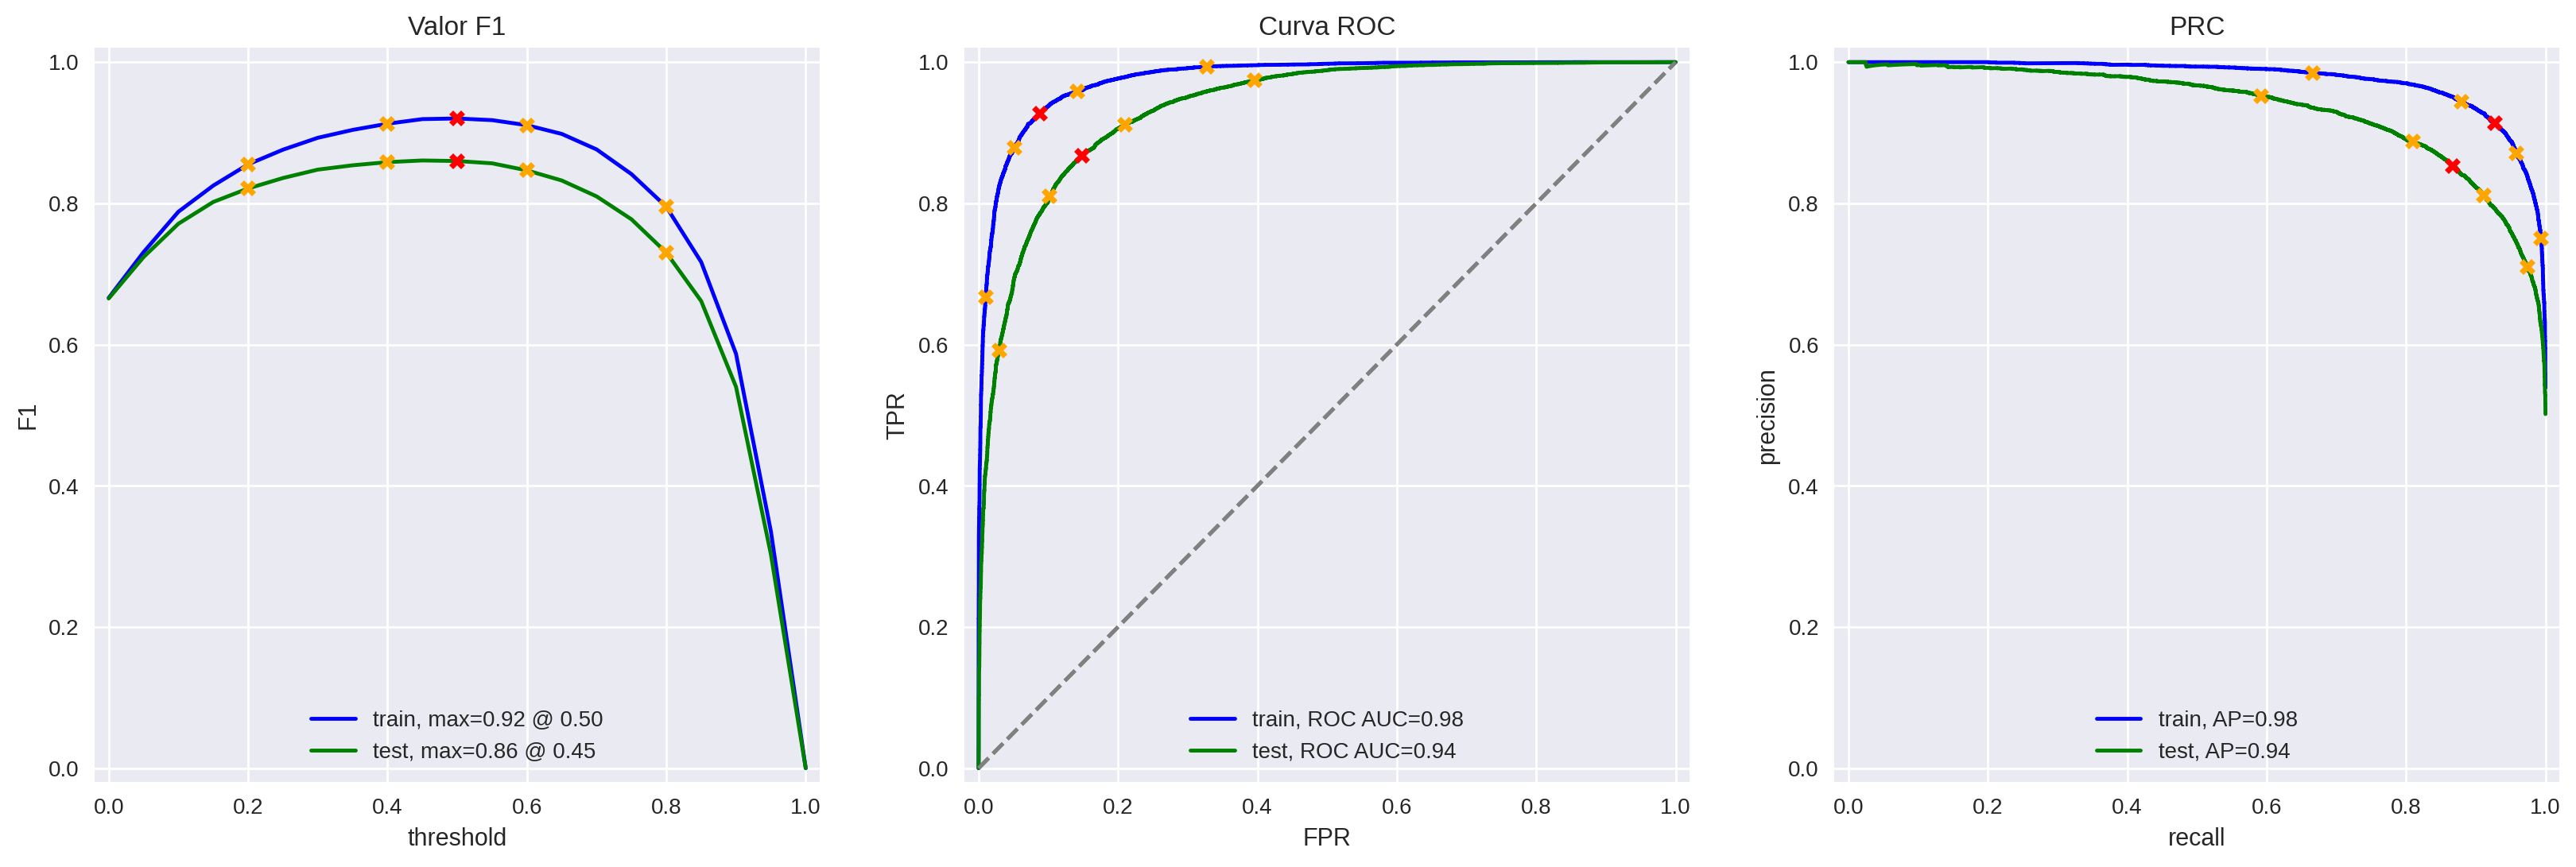

In [39]:
# Evaluar el modelo con la función de evaluación
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

###  Modelo 9 - BERT

In [40]:
# tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
# config = transformers.BertConfig.from_pretrained('bert-base-uncased')
# model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [41]:
# def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
#     ids_list = []
#     attention_mask_list = []

#     # texto al id de relleno de tokens junto con sus máscaras de atención 
       
#     # <escribe tu código aquí para crear ids_list y attention_mask_list>
    
#     if force_device is not None:
#         device = torch.device(force_device)
#     else:
#         device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
#     model.to(device)
#     if not disable_progress_bar:
#         print(f'Uso del dispositivo {device}.')
    
#     # obtener insertados en lotes
    
#     embeddings = []

#     for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
#         ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
#         # <escribe tu código aquí para crear attention_mask_batch
            
#         with torch.no_grad():            
#             model.eval()
#             batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
#         embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
#     return np.concatenate(embeddings)

Se crea una función para convertir los textos en embeddings utilizando BERT. La función realiza tokenización, crea máscaras de atención, y ejecuta inferencia con BERT para generar embeddings.

Para transformar los textos de entrada en embeddings que pueden ser utilizados como características en modelos de clasificación u otras tareas de NLP. Los embeddings generados por BERT contienen información semántica rica y contextual, lo que mejora el desempeño de los modelos de machine learning.

In [42]:
# ¡Atención! La ejecución de BERT para miles de textos puede llevar mucho tiempo en la CPU, al menos varias horas
# train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

Llamamos a la función BERT_text_to_embeddings para transformar los textos normalizados del conjunto de entrenamiento en embeddings. Este paso es crucial para preparar los datos antes del entrenamiento del modelo. Al utilizar los embeddings generados por BERT, estamos utilizando una representación densa y significativa de los textos, lo cual mejora la capacidad del modelo para aprender patrones complejos.

In [43]:
# Comprobar formas de las características y objetivos de entrenamiento

# print(df_reviews_train['review_norm'].shape)
# print(train_features_9.shape)
# print(train_target.shape)

In [44]:
# si ya obtuviste los insertados, te recomendamos guardarlos para tenerlos listos si
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# y cargar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

Incluimos código (comentado) para guardar los embeddings generados en un archivo comprimido y para cargarlos posteriormente.

Generar embeddings con BERT es una operación intensiva en términos de tiempo y recursos computacionales. Guardar los resultados permite reutilizarlos sin necesidad de recalcularlos, optimizando así el flujo de trabajo. Comentar estos bloques de código sirve como una guía para guardar/cargar los embeddings en futuras ejecuciones, evitando recomputaciones innecesarias y ahorrando tiempo y recursos.

## Mis reseñas

In [45]:
# puedes eliminar por completo estas reseñas y probar tus modelos en tus propias reseñas; las que se muestran a continuación son solo ejemplos

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

"""
my_reviews = pd.DataFrame([
    'Simplemente no me gustó, no es mi tipo de película.',
    'Bueno, estaba aburrido y me quedé dormido a media película.',
    'Estaba realmente fascinada con la película',    
    'Hasta los actores parecían muy viejos y desinteresados, y les pagaron por estar en la película. Qué robo tan desalmado.',
    '¡No esperaba que el relanzamiento fuera tan bueno! Los escritores realmente se preocuparon por el material original',
    'La película tuvo sus altibajos, pero siento que, en general, es una película decente. Sí la volvería a ver',
    'Qué pésimo intento de comedia. Ni una sola broma tiene sentido, todos actúan de forma irritante y ruidosa, ¡ni siquiera a los niños les gustará esto!',
    'Fue muy valiente el lanzamiento en Netflix y realmente aprecio poder seguir viendo episodio tras episodio de este nuevo drama tan emocionante e inteligente.'
], columns=['review'])
"""

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didnt expect the reboot to be so good writer...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i reall...


In [46]:
my_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review       8 non-null      object
 1   review_norm  8 non-null      object
dtypes: object(2)
memory usage: 256.0+ bytes


### Modelo 2

In [49]:
# Cargar el modelo entrenado
model_1 = joblib.load('model_1.pkl')

# Cargar el vectorizador TF-IDF
tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Transformar las reseñas normalizadas usando el vectorizador TF-IDF cargado
my_reviews_features_2 = tfidf_vectorizer.transform(my_reviews['review_norm'])

# Realizar predicciones en nuevas reseñas
my_reviews_pred_prob = model_1.predict_proba(my_reviews_features_2)[:, 1]

# Imprimir resultados
for i, review in enumerate(my_reviews['review']):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.16:  I did not simply like it, not my kind of movie.
0.18:  Well, I was bored and felt asleep in the middle of the movie.
0.56:  I was really fascinated with the movie
0.13:  Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.
0.26:  I didn't expect the reboot to be so good! Writers really cared about the source material
0.48:  The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see myself going to see it again.
0.05:  What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won't like this!
0.84:  Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.


### Modelo 3

In [51]:
# Cargar el modelo y el vectorizador
model_3 = joblib.load('model_3.pkl')

tfidf_vectorizer_3 = joblib.load('tfidf_vectorizer_3.pkl')

# Cargar el modelo de spaCy para el preprocesamiento
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Preprocesar el texto
my_reviews['review_norm'] = my_reviews['review'].apply(text_preprocessing_3)

# Transformar las características textuales
texts_transformed_spacy = tfidf_vectorizer_3.transform(my_reviews['review_norm'])

# Realizar predicciones
my_reviews_pred_prob = model_3.predict_proba(texts_transformed_spacy)[:, 1]

# Mostrar resultados
for i, review in enumerate(my_reviews['review']):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.15:  I did not simply like it, not my kind of movie.
0.20:  Well, I was bored and felt asleep in the middle of the movie.
0.50:  I was really fascinated with the movie
0.19:  Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.
0.19:  I didn't expect the reboot to be so good! Writers really cared about the source material
0.68:  The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see myself going to see it again.
0.03:  What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won't like this!
0.87:  Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.


### Modelo 4

In [53]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_4
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_4(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.51:  I do not simply like it , not my kind of movie .
0.45:  well , I be bored and feel asleep in the middle of the movie .
0.60:  I be really fascinated with the movie
0.61:  even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.43:  I do not expect the reboot to be so good ! writer really care about the source material
0.79:  the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.17:  what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
0.76:  launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode , 


### Modelo 9

In [54]:
# texts = df_reviews_train['review_norm']
# labels = df_reviews_train['label']  # Asumiendo que existe una columna con las etiquetas

# # Paso 1: Obtener los embeddings de BERT
# train_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

# # Paso 2: Dividir los datos en conjunto de entrenamiento y validación
# X_train, X_val, y_train, y_val = train_test_split(train_features_9, labels, test_size=0.2, random_state=42)

# # Paso 3: Entrenar el modelo de regresión logística
# model_9 = LogisticRegression(max_iter=1000)
# model_9.fit(X_train, y_train)

# # Paso 4: Evaluar el modelo (opcional)
# val_accuracy = model_9.score(X_val, y_val)
# print(f'Accuracy en validación: {val_accuracy:.2f}')

# # Paso 5: Guardar el modelo entrenado
# joblib.dump(model_9, './model_9.pkl')

In [55]:
# # Paso 3: Cargar tu modelo de regresión logística preentrenado
# model_9 = joblib.load('model_3.pkl')

# # Paso 4: Obtener las características usando BERT
# texts = my_reviews['review_norm']
# my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

# # Paso 5: Hacer predicciones con el modelo de regresión logística
# my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

# # Paso 6: Imprimir las predicciones
# for i, review in enumerate(texts.str.slice(0, 100)):
#     print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

## Conclusiones

Hemos evaluado tres modelos para la clasificación de sentimientos en reseñas de películas para entender si las reseñas de películas son positivas, negativas o una mezcla. La clasificación se basa en una escala de 0 a 1, donde 0 es muy negativo y 1 es muy positivo. A continuación, se describen los resultados obtenidos por cada modelo:

- **Modelo 2:** Los resultados varían de 0.05 a 0.84, con una precisión general aceptable.

    - Pros:
        - **Precisión General Aceptable:** En general, este modelo es bastante bueno para identificar el sentimiento.
        - **Detecta lo Muy Negativo:** Es excelente reconociendo reseñas claramente negativas, dándoles un puntaje muy bajo (cercano a 0). Por ejemplo, una reseña como "What a rotten attempt at a comedy" la clasificó correctamente con un 0.05.
    
    - Contras:
        - **Inconsistencia con Sentimientos Mixtos:** Su principal debilidad es que no siempre acierta con reseñas que tienen sentimientos mezclados o matices (por ejemplo, "The movie had its upsides and downsides", onteniendo un 0.48). Para estas, su clasificación puede ser un poco confusa, lo que significa que no las "entiende" completamente.
        
- **Modelo 3:** Muestra una mejora notable en la coherencia de las clasificaciones, con puntajes que van desde 0.03 a 0.87.

    - Pros:
        - **Coherencia Mejorada:** Este modelo es mucho más consistente en sus clasificaciones, lo que significa que sus resultados son más fiables.
        - **Diferenciación de Sentimientos Mixtos:** Es muy bueno distinguiendo reseñas con sentimientos combinados, dándoles un puntaje que refleja ese balance. Por ejemplo, la reseña "The movie had its upsides and downsides" obtuvo un 0.68, mostrando que captó tanto lo positivo como lo negativo.
        - **Identificación Clara de Positivos:** Reconoce las reseñas positivas con gran claridad, asignándoles puntajes altos (cercanos a 1). Por ejemplo, una reseña como "Launching on Netflix was a brave move," recibió un puntaje de 0.87.
        
    - Contras:
        - No se identificaron debilidades significativas en este modelo.
        
- **Modelo 4:** Este modelo presenta una mayor variabilidad en los resultados, con puntajes que oscilan entre 0.17 y 0.79.

    - Pros:
        - **Reconocimiento Básico:** Puede identificar correctamente las reseñas que son muy positivas o muy negativas.
    
    - Contras:
        - **Mayor Variabilidad:** Sus resultados pueden variar más, lo que lo hace menos predecible.
        - **Sesgo Hacia lo Positivo:** Tiene una tendencia a "sobreestimar" el sentimiento positivo, incluso en reseñas que son negativas o mixtas. Por ejemplo, una reseña claramente negativa como "Even the actors looked really old and disinterested" fue clasificada con un 0.61, lo cual no concuerda con el sentimiento real. Esto reduce su fiabilidad.


**Conclusión:** Después de comparar los tres modelos, el **Modelo 3** es claramente la mejor opción. Demostró ser el más equilibrado y preciso en su capacidad para clasificar sentimientos, logrando una mejor distinción entre reseñas positivas, negativas y aquellas con sentimientos mixtos. Aunque el **Modelo 2** es aceptable, su inconsistencia en los matices lo deja atrás. El **Modelo 4**, por su parte, no es tan fiable debido a su tendencia a ver lo positivo donde no lo hay. Por lo tanto, el **Modelo 3** es la base más sólida para cualquier futura aplicación de análisis de sentimientos en textos.



# Lista de comprobación

- [x]  Abriste el notebook
- [ ]  Cargaste y preprocesaste los datos de texto para su vectorización
- [ ]  Transformaste los datos de texto en vectores
- [ ]  Entrenaste y probaste los modelos
- [ ]  Se alcanzó el umbral de la métrica
- [ ]  Colocaste todas las celdas de código en el orden de su ejecución
- [ ]  Puedes ejecutar sin errores todas las celdas de código 
- [ ]  Hay conclusiones 